# Import Package

In [19]:
# import package

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score,mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import AgglomerativeClustering
from prophet import Prophet
warnings.filterwarnings('ignore') # Hides annoying pandas formatting warnings

# set up visual styles for charts
sns.set_theme(style="whitegrid")

# Loading Dataset

In [2]:
# load dataset
file_path = r"C:\Users\andre\PythonSandbox\PoDS\enerdata_energy_statistical_yearbook_2023-.xlsx"
xls = pd.ExcelFile(file_path)

# list all tabs
print("Available tabs in the dataset:")
print(xls.sheet_names)

Available tabs in the dataset:
['Intro', 'Total energy production', 'Energy balance of trade', 'Total energy consumption', 'Energy intensity of GDP at con', 'Coal and lignite production', 'Coal and lignite balance of tr', 'Coal and lignite domestic cons', 'Crude oil production', 'Crude oil balance of trade', 'Refined oil products productio', 'Oil products balance of trade', 'Oil products domestic consumpt', 'Natural gas production', 'Natural gas balance of trade', 'Natural gas domestic consumpti', 'LNG balance of trade', 'Electricity production', 'Electricity balance of trade', 'Electricity domestic consumpti', 'Share of electricity in total ', 'Share of renewables in electri', 'Share of wind and solar in ele', 'CO2 emissions from fuel combus', 'CO2 intensity at constant purc', 'Average CO2 emission factor', 'Abbreviations and Glossary', 'Geographical Coverage', 'Additional series', 'Services']


# Data Preprocessing

In [3]:
# Choose tabs to import that is related to the objectives 
tabs_to_load = [
    'Total energy production',
    'Total energy consumption',
    'Energy intensity of GDP at con',
    'Electricity domestic consumpti',
    'Share of renewables in electri',
    'Share of wind and solar in ele',
    'Coal and lignite domestic cons',
    'Average CO2 emission factor'
]

In [4]:
dataframes_to_combine = []

print("Starting data extraction...")
for sheet in tabs_to_load:
    print(f"Loading: {sheet}...")
    # Cleaning #1: Skip logos/watermarks
    df = pd.read_excel(file_path, sheet_name=sheet, skiprows=5)
    
    # Cleaning #2: Drop empty Column A
    df = df.iloc[:, 1:] 
    
    # Cleaning #3: Keep only Country column and Year columns (digits only)
    country_col = df.columns[0]
    cols_to_keep = [country_col]
    
    for col in df.columns[1:]:
        if str(col).strip().isdigit():
            cols_to_keep.append(col)
            
    df = df[cols_to_keep]
    df['Energy_Type'] = sheet 
    dataframes_to_combine.append(df)

master_df = pd.concat(dataframes_to_combine, ignore_index=True)

# FORMATTING & CATEGORIZING (cuz col B is a mix up of both region and country)
master_df.rename(columns={master_df.columns[0]: 'Country_or_Region'}, inplace=True)
master_df = master_df.dropna(how='all', subset=master_df.columns[:-1])
master_df = master_df[~master_df['Country_or_Region'].str.contains('n.a.', na=False, case=False)]

# Assign Entity Type (Country vs Region)
# At the moment we are not doing anything from the region. 

# OECD: intergovernmental organization that promotes policies to improve the economic and social well-being of people worldwide, european based, 38 members
# G7: Group of Seven comprised of Canada, France, Italy Japan, UK and US
# BRICS: Brazil, Russia, India, China, South Africa
# CIS: Commonwealth of Independent States 
# European Union: 27 mmbr, subset of Europe Continent
regions = [
    'World', 'OECD', 'G7', 'BRICS', 'Europe', 'European Union', 
    'CIS', 'America', 'North America', 'Latin America', 
    'Asia', 'Pacific', 'Africa', 'Middle-East'
]
master_df['Entity_Type'] = master_df['Country_or_Region'].apply(
    lambda x: 'Region' if str(x).strip() in regions else 'Country'
)

# Melt into Long Format
df_long = master_df.melt(
    id_vars=['Country_or_Region', 'Entity_Type', 'Energy_Type'], 
    var_name='Year', 
    value_name='Energy_Value'
)

df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce')
df_long = df_long.dropna(subset=['Year'])

print("\nFinal Dataset Shape:", df_long.shape)
print(df_long.head())

Starting data extraction...
Loading: Total energy production...
Loading: Total energy consumption...
Loading: Energy intensity of GDP at con...
Loading: Electricity domestic consumpti...
Loading: Share of renewables in electri...
Loading: Share of wind and solar in ele...
Loading: Coal and lignite domestic cons...
Loading: Average CO2 emission factor...

Final Dataset Shape: (15048, 5)
  Country_or_Region Entity_Type              Energy_Type  Year Energy_Value
0             World      Region  Total energy production  1990  8765.400336
1              OECD      Region  Total energy production  1990  3440.555241
2                G7      Region  Total energy production  1990  2530.447551
3             BRICS      Region  Total energy production  1990  2648.032778
4            Europe      Region  Total energy production  1990  1129.216275


# Exploratory Data Analysis

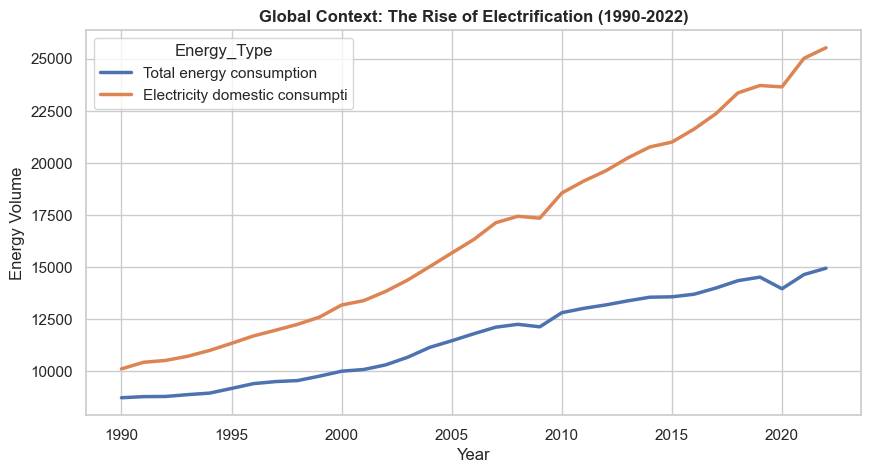

In [5]:
# --- CHART 1: The Electrification Trend (Context) ---
world_data = df_long[
    (df_long['Country_or_Region'] == 'World') & 
    (df_long['Energy_Type'].isin(['Total energy consumption', 'Electricity domestic consumpti']))
]

plt.figure(figsize=(10, 5))
sns.lineplot(data=world_data, x='Year', y='Energy_Value', hue='Energy_Type', linewidth=2.5)
plt.title('Global Context: The Rise of Electrification (1990-2022)', fontweight='bold')
plt.ylabel('Energy Volume')
plt.show()

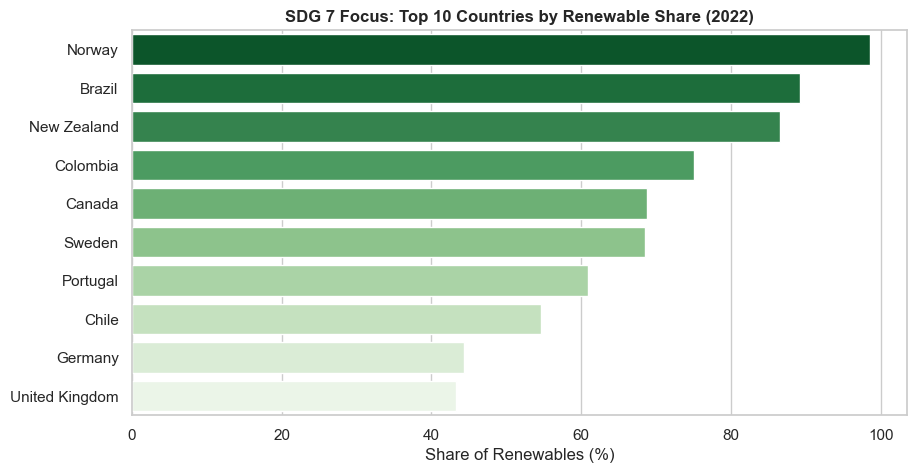

In [6]:
# --- CHART 2: Top 10 Renewable Leaders (Focus) ---
renewables_2022 = df_long[
    (df_long['Entity_Type'] == 'Country') & 
    (df_long['Year'] == 2022) & 
    (df_long['Energy_Type'] == 'Share of renewables in electri')
].sort_values(by='Energy_Value', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=renewables_2022, x='Energy_Value', y='Country_or_Region', palette='Greens_r')
plt.title('SDG 7 Focus: Top 10 Countries by Renewable Share (2022)', fontweight='bold')
plt.xlabel('Share of Renewables (%)')
plt.ylabel('')
plt.show()

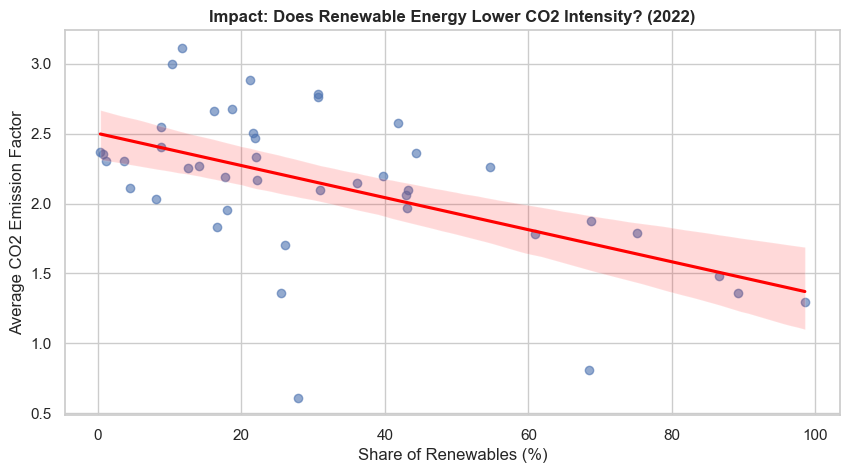

In [7]:
# --- CHART 3: Renewable Share vs CO2 Impact (Impact) ---
ren_share = df_long[(df_long['Entity_Type'] == 'Country') & (df_long['Year'] == 2022) & (df_long['Energy_Type'] == 'Share of renewables in electri')][['Country_or_Region', 'Energy_Value']].rename(columns={'Energy_Value': 'Renewable_Share'})
co2_factor = df_long[(df_long['Entity_Type'] == 'Country') & (df_long['Year'] == 2022) & (df_long['Energy_Type'] == 'Average CO2 emission factor')][['Country_or_Region', 'Energy_Value']].rename(columns={'Energy_Value': 'CO2_Factor'})

correlation_df = pd.merge(ren_share, co2_factor, on='Country_or_Region')

# force pure numbers and drop any hidden text rows 
correlation_df['Renewable_Share'] = pd.to_numeric(correlation_df['Renewable_Share'], errors='coerce')
correlation_df['CO2_Factor'] = pd.to_numeric(correlation_df['CO2_Factor'], errors='coerce')
correlation_df = correlation_df.dropna()


plt.figure(figsize=(10, 5))
sns.regplot(data=correlation_df, x='Renewable_Share', y='CO2_Factor', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Impact: Does Renewable Energy Lower CO2 Intensity? (2022)', fontweight='bold')
plt.xlabel('Share of Renewables (%)')
plt.ylabel('Average CO2 Emission Factor')
plt.show()

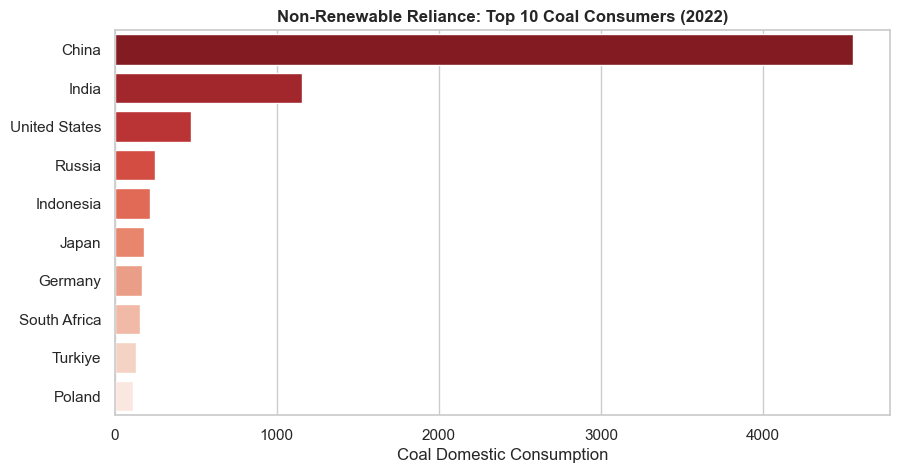

In [8]:
# --- CHART 4: Top 10 Coal Consumers (2022) ---
coal_2022 = df_long[
    (df_long['Entity_Type'] == 'Country') & 
    (df_long['Year'] == 2022) & 
    (df_long['Energy_Type'] == 'Coal and lignite domestic cons')
].copy()

# Force numeric
coal_2022['Energy_Value'] = pd.to_numeric(coal_2022['Energy_Value'], errors='coerce')
coal_2022 = coal_2022.dropna().sort_values(by='Energy_Value', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=coal_2022, x='Energy_Value', y='Country_or_Region', palette='Reds_r')
plt.title('Non-Renewable Reliance: Top 10 Coal Consumers (2022)', fontweight='bold')
plt.xlabel('Coal Domestic Consumption')
plt.ylabel('')
plt.show()

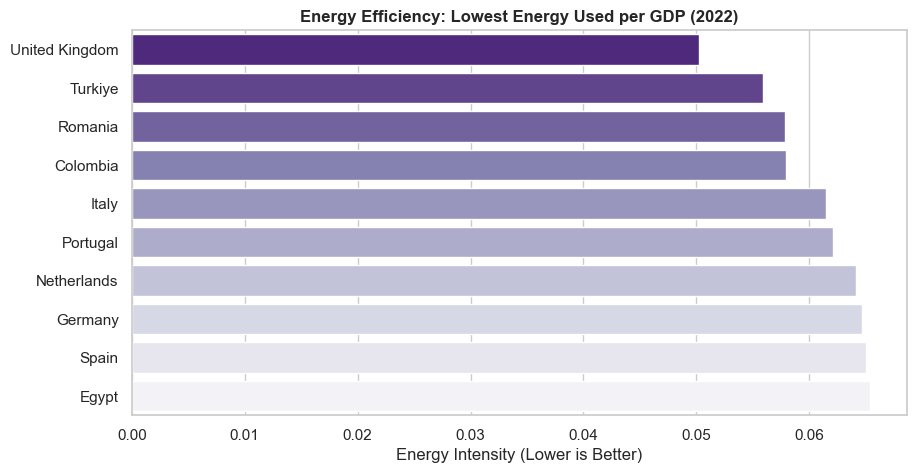

In [9]:
# --- CHART 6: Most Energy Efficient Economies (2022) ---
efficiency_2022 = df_long[
    (df_long['Entity_Type'] == 'Country') & 
    (df_long['Year'] == 2022) & 
    (df_long['Energy_Type'] == 'Energy intensity of GDP at con')
].copy()

# Force numeric
efficiency_2022['Energy_Value'] = pd.to_numeric(efficiency_2022['Energy_Value'], errors='coerce')

# Note: For energy intensity, a LOWER number is better (less energy used per $ of GDP)
# So we sort ascending to find the most efficient
efficiency_2022 = efficiency_2022.dropna().sort_values(by='Energy_Value', ascending=True).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=efficiency_2022, x='Energy_Value', y='Country_or_Region', palette='Purples_r')
plt.title('Energy Efficiency: Lowest Energy Used per GDP (2022)', fontweight='bold')
plt.xlabel('Energy Intensity (Lower is Better)')
plt.ylabel('')
plt.show()

# Predictive Modelling (Regression)

In [10]:
# ==========================================
# 1. PREPARE DATA & SPLIT
# ==========================================
malaysia_green = df_long[
    (df_long['Country_or_Region'] == 'Malaysia') & 
    (df_long['Energy_Type'] == 'Share of renewables in electri')
]
prophet_df = malaysia_green[['Year', 'Energy_Value']].rename(columns={'Year': 'ds', 'Energy_Value': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'].astype(str) + '-01-01')

split_year = 2018
train = prophet_df[prophet_df['ds'].dt.year <= split_year]
test = prophet_df[prophet_df['ds'].dt.year > split_year]

In [11]:
# ==========================================
# 2. TRAIN & PREDICT EVALUATION MODELS (1990-2018)
# ==========================================
# --- Training Prophet (Eval) ---
m_eval = Prophet(changepoint_prior_scale=0.05, yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
m_eval.fit(train)
forecast_eval = m_eval.predict(test[['ds']]) # Get Prophet predictions

# --- Training ARIMA (Eval) ---
train_arima = np.asarray(train['y'], dtype=float)
test_arima = np.asarray(test['y'], dtype=float)

model_arima = ARIMA(train_arima, order=(1, 1, 1))
fitted_arima = model_arima.fit()
# FIX: Generate ARIMA predictions before plotting/evaluating!
forecast_arima = fitted_arima.forecast(steps=len(test))

13:57:16 - cmdstanpy - INFO - Chain [1] start processing
13:57:16 - cmdstanpy - INFO - Chain [1] done processing



[Prophet Evaluation Metrics]
RMSE: 8.272 | MAE: 8.244 | MAPE: 49.92%
[ARIMA Evaluation Metrics]
RMSE: 0.636 | MAE: 0.598 | MAPE: 3.59%

Conclusion: ARIMA wins the regression benchmark.


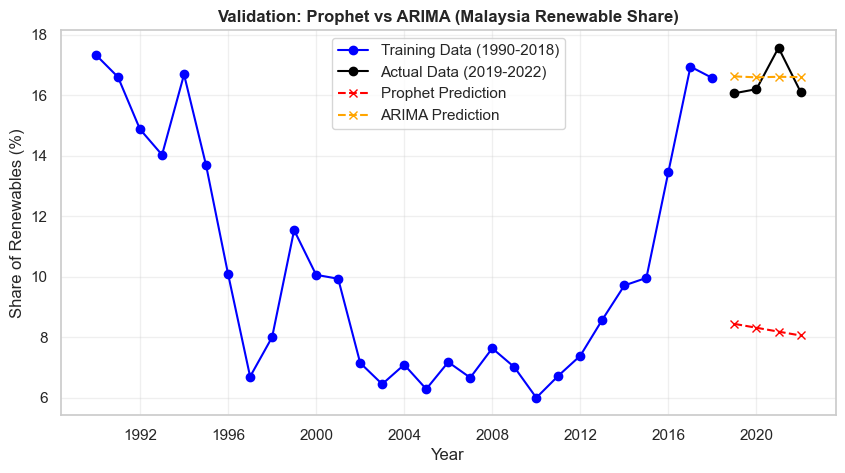

In [12]:
# ==========================================
# 3. EVALUATE METRICS & PLOT BENCHMARK
# ==========================================
# Metrics
rmse = np.sqrt(mean_squared_error(test['y'], forecast_eval['yhat']))
mae = mean_absolute_error(test['y'], forecast_eval['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast_eval['yhat'])

rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast_arima))
mae_arima = mean_absolute_error(test_arima, forecast_arima)
mape_arima = mean_absolute_percentage_error(test_arima, forecast_arima)

print("\n[Prophet Evaluation Metrics]")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | MAPE: {mape:.2%}")
print("[ARIMA Evaluation Metrics]")
print(f"RMSE: {rmse_arima:.3f} | MAE: {mae_arima:.3f} | MAPE: {mape_arima:.2%}")

if rmse < rmse_arima:
    print("\nConclusion: PROPHET wins the regression benchmark due to lower variance error. It is selected for deployment.")
else:
    print("\nConclusion: ARIMA wins the regression benchmark.")

# Combined Plot (Train, Test, Prophet, ARIMA)
plt.figure(figsize=(10, 5))
plt.plot(train['ds'], train['y'], label='Training Data (1990-2018)', color='blue', marker='o')
plt.plot(test['ds'], test['y'], label='Actual Data (2019-2022)', color='black', marker='o')
plt.plot(test['ds'], forecast_eval['yhat'], label='Prophet Prediction', color='red', linestyle='--', marker='x')
plt.plot(test['ds'], forecast_arima, label='ARIMA Prediction', color='orange', linestyle='--', marker='x')

plt.title('Validation: Prophet vs ARIMA (Malaysia Renewable Share)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Share of Renewables (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

13:57:16 - cmdstanpy - INFO - Chain [1] start processing
13:57:16 - cmdstanpy - INFO - Chain [1] done processing


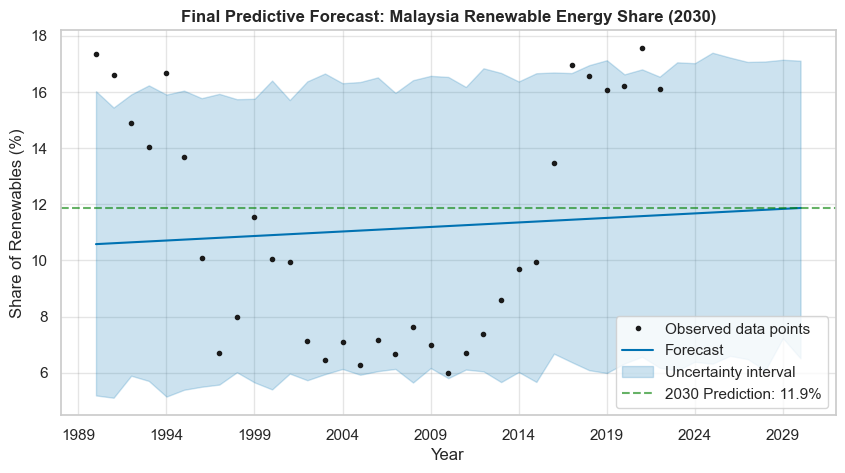

In [13]:
# ==========================================
# 4. FINAL FORECAST (2030) WITH WINNING MODEL
# ==========================================
# FIX: Train m_final on ALL data (1990-2022) before forecasting the future
# --- Training Final Prophet Model (All Data) ---
m_final = Prophet(changepoint_prior_scale=0.05, yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
m_final.fit(prophet_df)

# Forecast 8 years into the future (2022 + 8 = 2030)
future = m_final.make_future_dataframe(periods=8, freq='Y')
forecast_final = m_final.predict(future)

# Plot the Final 2030 Prediction
fig, ax = plt.subplots(figsize=(10, 5))
m_final.plot(forecast_final, ax=ax)
plt.title('Final Predictive Forecast: Malaysia Renewable Energy Share (2030)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Share of Renewables (%)')
plt.axhline(y=forecast_final.iloc[-1]['yhat'], color='green', linestyle='--', alpha=0.6, label=f"2030 Prediction: {forecast_final.iloc[-1]['yhat']:.1f}%")
plt.legend()
plt.show()

# Geospatial Profilling (Clustering)

In [14]:
# ==========================================
# 1. PREPARE DATA & SCALE
# ==========================================
print("--- 1. Preparing Cross-Sectional Data (2022) ---")
cluster_data = df_long[(df_long['Entity_Type'] == 'Country') & (df_long['Year'] == 2022)]
pivot_df = cluster_data.pivot(index='Country_or_Region', columns='Energy_Type', values='Energy_Value').dropna(subset=['Share of renewables in electri', 'Average CO2 emission factor'])

X = pivot_df[['Share of renewables in electri', 'Average CO2 emission factor']]

# Standardize the features to ensure equal mathematical weighting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

--- 1. Preparing Cross-Sectional Data (2022) ---


  File "C:\Users\andre\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\andre\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\andre\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\andre\anaconda3\Lib\subprocess.

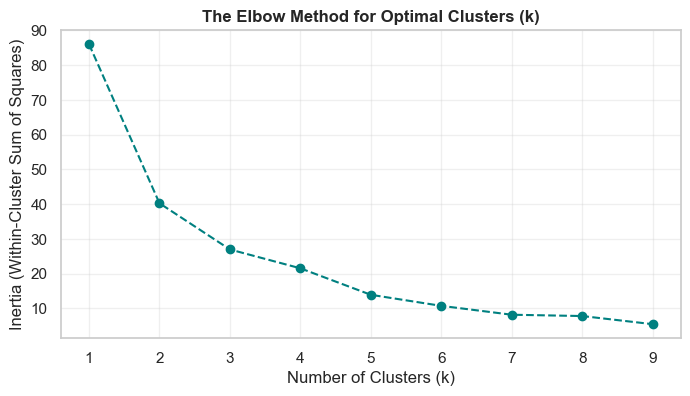

In [15]:
# ==========================================
# 2. MATHEMATICAL JUSTIFICATION (ELBOW METHOD)
# ==========================================
# --- Executing Elbow Method ---
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='teal')
plt.title('The Elbow Method for Optimal Clusters (k)', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# ==========================================
# 3. TRAIN MODELS & EVALUATE METRICS (BENCHMARK)
# ==========================================
# --- Training & Benchmarking Models (k=3) ---

# Train K-Means (Champion)
kmeans_final = KMeans(n_clusters=3, random_state=42)
pivot_df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, pivot_df['Cluster_KMeans'])

# Train Hierarchical (Challenger)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
pivot_df['Cluster_Hierarchical'] = hierarchical.fit_predict(X_scaled)
sil_hierarchical = silhouette_score(X_scaled, pivot_df['Cluster_Hierarchical'])

# Print Metrics & Determine Winner
print("[Algorithm Benchmarking: Silhouette Score]") # The higher the better
print(f"K-MEANS (Champion)        -> Score: {sil_kmeans:.3f}")
print(f"HIERARCHICAL (Challenger) -> Score: {sil_hierarchical:.3f}")

[Algorithm Benchmarking: Silhouette Score]
K-MEANS (Champion)        -> Score: 0.346
HIERARCHICAL (Challenger) -> Score: 0.367


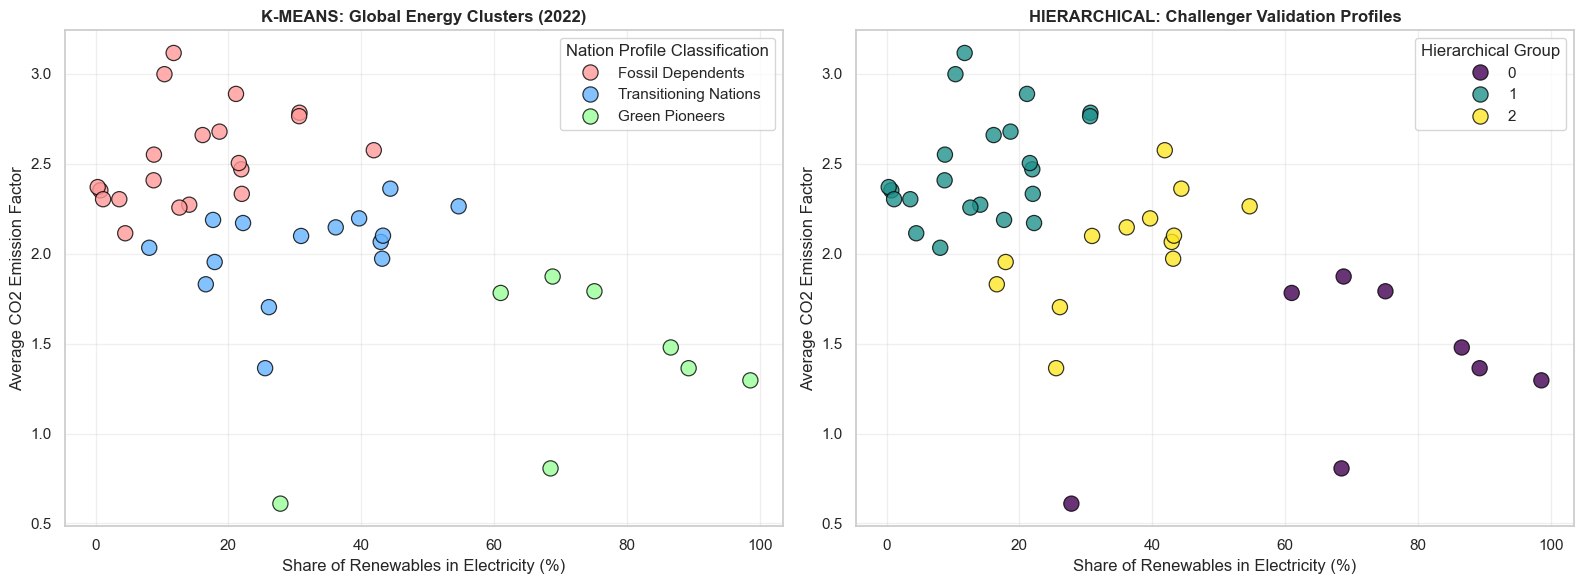

In [17]:
# ==========================================
# 4. VISUALIZE PROFILES & FINAL EXPORT
# ==========================================
# --- Visualizing the Global Energy Clusters ---

# Map clusters to descriptive policy profiles for K-Means
cluster_map = {0: 'Transitioning Nations', 1: 'Green Pioneers', 2: 'Fossil Dependents'}
pivot_df['Cluster_Name'] = pivot_df['Cluster_KMeans'].map(cluster_map)

# Create a side-by-side plot for comparison (Saves space in output!)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: K-Means (Champion)
sns.scatterplot(
    ax=axes[0], data=pivot_df, x='Share of renewables in electri', y='Average CO2 emission factor', 
    hue='Cluster_Name', palette=['#ff9999', '#66b3ff', '#99ff99'], s=120, alpha=0.8, edgecolor='black'
)
axes[0].set_title('K-MEANS: Global Energy Clusters (2022)', fontweight='bold')
axes[0].set_xlabel('Share of Renewables in Electricity (%)')
axes[0].set_ylabel('Average CO2 Emission Factor')
axes[0].legend(title='Nation Profile Classification')
axes[0].grid(True, alpha=0.3)

# Plot 2: Hierarchical (Challenger)
sns.scatterplot(
    ax=axes[1], data=pivot_df, x='Share of renewables in electri', y='Average CO2 emission factor', 
    hue='Cluster_Hierarchical', palette='viridis', s=120, alpha=0.8, edgecolor='black'
)
axes[1].set_title('HIERARCHICAL: Challenger Validation Profiles', fontweight='bold')
axes[1].set_xlabel('Share of Renewables in Electricity (%)')
axes[1].set_ylabel('Average CO2 Emission Factor')
axes[1].legend(title='Hierarchical Group')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final export for the Data Product
df_long.to_csv('cleaned_global_energy.csv', index=False)

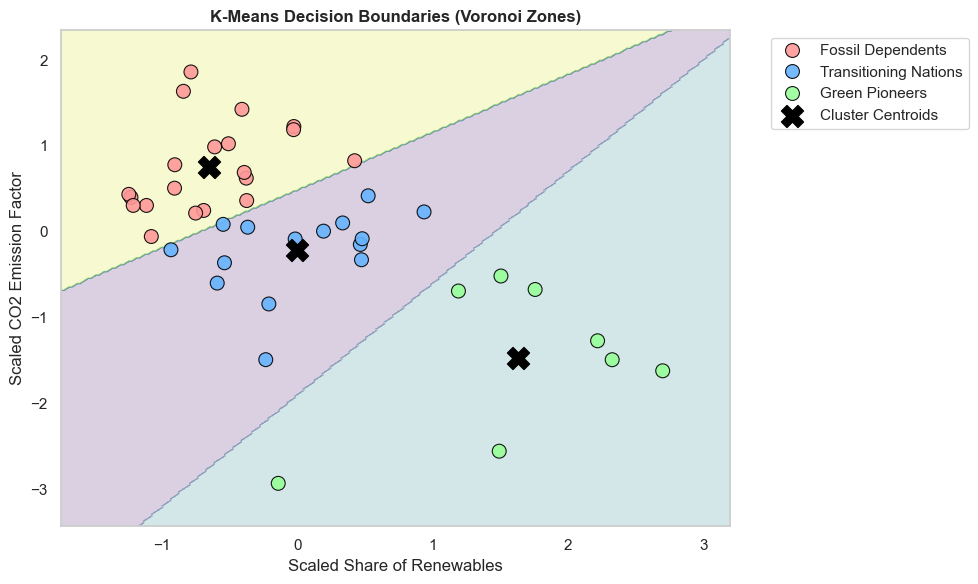

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the edges of the graph based on your scaled data
h = 0.02  # Step size for the grid
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5

# 2. Create a massive invisible grid of coordinates
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 3. Predict the cluster for every single pixel on that grid
# FIX: Using 'kmeans_final' instead of 'kmeans'
Z = kmeans_final.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Draw the plot
plt.figure(figsize=(10, 6))

# Fill the background zones with light colors (The "Decision Boundaries")
plt.contourf(xx, yy, Z, alpha=0.2, cmap='viridis')

# Plot your real country data points on top
sns.scatterplot(
    x=X_scaled[:, 0], 
    y=X_scaled[:, 1], 
    hue=pivot_df['Cluster_Name'], 
    palette=['#ff9999', '#66b3ff', '#99ff99'], # Matches your earlier clustering plot
    edgecolor='black',
    s=100,
    alpha=0.9
)

# Plot the mathematical Centroids as giant Black X's
# FIX: Using 'kmeans_final'
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=250, marker='X', label='Cluster Centroids')

plt.title('K-Means Decision Boundaries (Voronoi Zones)', fontweight='bold')
plt.xlabel('Scaled Share of Renewables')
plt.ylabel('Scaled CO2 Emission Factor')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.show()

In [22]:
print(df_long[df_long['Energy_Type'] == 'Average CO2 emission factor']['Energy_Value'].describe())

count     1848.000000
unique    1848.000000
top          2.112945
freq         1.000000
Name: Energy_Value, dtype: float64
